In [8]:
import gdown

files = {
    "wgm_full_wave2_public_file_final (1)_csv.csv": "1UHKht9LFpcCMmqSNDqFpMmpubJFIzP8S",
    "Countries by continents.csv": "1VhqCnarsOKQAmGQ_X40hFB9TNSzF4hf8",
    "wikipedia-iso-country-codes.csv": "1v9EL-dKRKryzzXIPKnExSoaHToL4zbsF",
    "16BBF41_ALL_LATEST.csv": "1iSCVOHHxtlPqO3qd9TVXj_yKFyeCcOLv",
    "countries.geo.json": "1IpPqEYHYKGaQH0gpicFb_tVlBXR8FXUP"
}

for filename, file_id in files.items():
    url = f"https://drive.google.com/uc?id={file_id}"
    gdown.download(url, filename, quiet=False)



Downloading...
From: https://drive.google.com/uc?id=1UHKht9LFpcCMmqSNDqFpMmpubJFIzP8S
To: /content/wgm_full_wave2_public_file_final (1)_csv.csv
100%|██████████| 27.3M/27.3M [00:00<00:00, 49.0MB/s]
Downloading...
From: https://drive.google.com/uc?id=1VhqCnarsOKQAmGQ_X40hFB9TNSzF4hf8
To: /content/Countries by continents.csv
100%|██████████| 3.61k/3.61k [00:00<00:00, 11.5MB/s]
Downloading...
From: https://drive.google.com/uc?id=1v9EL-dKRKryzzXIPKnExSoaHToL4zbsF
To: /content/wikipedia-iso-country-codes.csv
100%|██████████| 9.45k/9.45k [00:00<00:00, 24.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1iSCVOHHxtlPqO3qd9TVXj_yKFyeCcOLv
To: /content/16BBF41_ALL_LATEST.csv
100%|██████████| 2.74M/2.74M [00:00<00:00, 37.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=1IpPqEYHYKGaQH0gpicFb_tVlBXR8FXUP
To: /content/countries.geo.json
100%|██████████| 257k/257k [00:00<00:00, 79.1MB/s]


In [9]:
import json

with open('countries.geo.json', 'r') as f:
    data = json.load(f)

data.keys() if isinstance(data, dict) else type(data)

dict_keys(['type', 'features'])

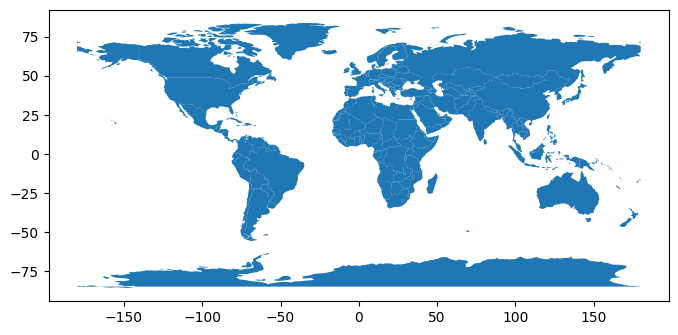

In [10]:
import geopandas as gpd
import matplotlib.pyplot as plt

gdf = gpd.read_file('countries.geo.json')

gdf.plot(figsize=(8, 8))
plt.show()


In [11]:
import pandas as pd

df = pd.read_csv('16BBF41_ALL_LATEST.csv')
print(df.head())

              IND_ID    IND_CODE IND_UUID IND_PER_CODE  DIM_TIME  \
0  16BBF41SDGSUICIDE  SDGSUICIDE  16BBF41   SDGSUICIDE      2000   
1  16BBF41SDGSUICIDE  SDGSUICIDE  16BBF41   SDGSUICIDE      2000   
2  16BBF41SDGSUICIDE  SDGSUICIDE  16BBF41   SDGSUICIDE      2000   
3  16BBF41SDGSUICIDE  SDGSUICIDE  16BBF41   SDGSUICIDE      2000   
4  16BBF41SDGSUICIDE  SDGSUICIDE  16BBF41   SDGSUICIDE      2000   

  DIM_TIME_TYPE  DIM_GEO_CODE_M49 DIM_GEO_CODE_TYPE DIM_PUBLISH_STATE_CODE  \
0          YEAR                 1            GLOBAL              PUBLISHED   
1          YEAR                 1            GLOBAL              PUBLISHED   
2          YEAR                 1            GLOBAL              PUBLISHED   
3          YEAR                 4           COUNTRY              PUBLISHED   
4          YEAR                 4           COUNTRY              PUBLISHED   

         IND_NAME GEO_NAME_SHORT DIM_SEX DIM_AGE  RATE_PER_100000_N  \
0  Suicide deaths          World  FEMALE   TOTAL   

In [12]:
##view by country only
df = df[df['DIM_GEO_CODE_TYPE'] == 'COUNTRY']
print(df.head())


              IND_ID    IND_CODE IND_UUID IND_PER_CODE  DIM_TIME  \
3  16BBF41SDGSUICIDE  SDGSUICIDE  16BBF41   SDGSUICIDE      2000   
4  16BBF41SDGSUICIDE  SDGSUICIDE  16BBF41   SDGSUICIDE      2000   
5  16BBF41SDGSUICIDE  SDGSUICIDE  16BBF41   SDGSUICIDE      2000   
6  16BBF41SDGSUICIDE  SDGSUICIDE  16BBF41   SDGSUICIDE      2000   
7  16BBF41SDGSUICIDE  SDGSUICIDE  16BBF41   SDGSUICIDE      2000   

  DIM_TIME_TYPE  DIM_GEO_CODE_M49 DIM_GEO_CODE_TYPE DIM_PUBLISH_STATE_CODE  \
3          YEAR                 4           COUNTRY              PUBLISHED   
4          YEAR                 4           COUNTRY              PUBLISHED   
5          YEAR                 4           COUNTRY              PUBLISHED   
6          YEAR                 8           COUNTRY              PUBLISHED   
7          YEAR                 8           COUNTRY              PUBLISHED   

         IND_NAME GEO_NAME_SHORT DIM_SEX DIM_AGE  RATE_PER_100000_N  \
3  Suicide deaths    Afghanistan  FEMALE   TOTAL   

In [13]:
df_iso_code = pd.read_csv('wikipedia-iso-country-codes.csv')
print(df_iso_code.head())

  English short name lower case Alpha-2 code Alpha-3 code  Numeric code  \
0                   Afghanistan           AF          AFG             4   
1                 Åland Islands           AX          ALA           248   
2                       Albania           AL          ALB             8   
3                       Algeria           DZ          DZA            12   
4                American Samoa           AS          ASM            16   

      ISO 3166-2  
0  ISO 3166-2:AF  
1  ISO 3166-2:AX  
2  ISO 3166-2:AL  
3  ISO 3166-2:DZ  
4  ISO 3166-2:AS  


In [14]:
##join with iso code so it can join with geo json file later
df_merged = df.merge(
    df_iso_code,
    how='left',
    left_on='GEO_NAME_SHORT',
    right_on='English short name lower case'
)
print(df_merged.head())

              IND_ID    IND_CODE IND_UUID IND_PER_CODE  DIM_TIME  \
0  16BBF41SDGSUICIDE  SDGSUICIDE  16BBF41   SDGSUICIDE      2000   
1  16BBF41SDGSUICIDE  SDGSUICIDE  16BBF41   SDGSUICIDE      2000   
2  16BBF41SDGSUICIDE  SDGSUICIDE  16BBF41   SDGSUICIDE      2000   
3  16BBF41SDGSUICIDE  SDGSUICIDE  16BBF41   SDGSUICIDE      2000   
4  16BBF41SDGSUICIDE  SDGSUICIDE  16BBF41   SDGSUICIDE      2000   

  DIM_TIME_TYPE  DIM_GEO_CODE_M49 DIM_GEO_CODE_TYPE DIM_PUBLISH_STATE_CODE  \
0          YEAR                 4           COUNTRY              PUBLISHED   
1          YEAR                 4           COUNTRY              PUBLISHED   
2          YEAR                 4           COUNTRY              PUBLISHED   
3          YEAR                 8           COUNTRY              PUBLISHED   
4          YEAR                 8           COUNTRY              PUBLISHED   

         IND_NAME  ... DIM_SEX DIM_AGE RATE_PER_100000_N  RATE_PER_100000_NL  \
0  Suicide deaths  ...  FEMALE   TOTAL    

In [15]:
# see the most recent year, no need to split by gender and age for this plot
df_merged_2021 = df_merged[df_merged['DIM_TIME'] == 2021]
df_merged_2021 = df_merged_2021[df_merged_2021['DIM_SEX'] == "TOTAL"]
df_merged_2021 = df_merged_2021[df_merged_2021['DIM_AGE'] == "TOTAL"]

print(df_merged_2021.head())

                  IND_ID    IND_CODE IND_UUID IND_PER_CODE  DIM_TIME  \
10977  16BBF41SDGSUICIDE  SDGSUICIDE  16BBF41   SDGSUICIDE      2021   
10980  16BBF41SDGSUICIDE  SDGSUICIDE  16BBF41   SDGSUICIDE      2021   
10983  16BBF41SDGSUICIDE  SDGSUICIDE  16BBF41   SDGSUICIDE      2021   
10986  16BBF41SDGSUICIDE  SDGSUICIDE  16BBF41   SDGSUICIDE      2021   
10989  16BBF41SDGSUICIDE  SDGSUICIDE  16BBF41   SDGSUICIDE      2021   

      DIM_TIME_TYPE  DIM_GEO_CODE_M49 DIM_GEO_CODE_TYPE  \
10977          YEAR               792           COUNTRY   
10980          YEAR               795           COUNTRY   
10983          YEAR               800           COUNTRY   
10986          YEAR               804           COUNTRY   
10989          YEAR               807           COUNTRY   

      DIM_PUBLISH_STATE_CODE        IND_NAME  ... DIM_SEX DIM_AGE  \
10977              PUBLISHED  Suicide deaths  ...   TOTAL   TOTAL   
10980              PUBLISHED  Suicide deaths  ...   TOTAL   TOTAL   
10983

In [16]:
##some country names cannot be found, add iso code manually
df_merged_2021.loc[
    df_merged_2021['Alpha-3 code'].isna(),
    'GEO_NAME_SHORT'
].unique()



array(['Türkiye', 'North Macedonia',
       'United Kingdom of Great Britain and Northern Ireland',
       'United Republic of Tanzania', 'United States of America',
       'Venezuela (Bolivarian Republic of)', 'Viet Nam', 'South Sudan',
       'Eswatini', 'Netherlands (Kingdom of the)',
       'Micronesia (Federated States of)', 'Russian Federation',
       "Democratic People's Republic of Korea", 'Republic of Korea',
       'Libya', 'Republic of Moldova', 'Iran (Islamic Republic of)',
       'Cabo Verde', 'Democratic Republic of the Congo', 'Czechia',
       'Bolivia (Plurinational State of)'], dtype=object)

In [17]:
alpha3_fix = {
    'Cabo Verde': 'CPV',
    'Democratic Republic of the Congo': 'COD',
    'Czechia': 'CZE',
    'Iran (Islamic Republic of)': 'IRN',
    "Democratic People's Republic of Korea": 'PRK',
    'Republic of Korea': 'KOR',
    'Republic of Moldova': 'MDA',
    'Namibia': 'NAM',
    'Netherlands (Kingdom of the)': 'NLD',
    'Micronesia (Federated States of)': 'FSM',
    'Russian Federation': 'RUS',
    'Viet Nam': 'VNM',
    'South Sudan': 'SSD',
    'Eswatini': 'SWZ',
    'North Macedonia': 'MKD',
    'United Kingdom of Great Britain and Northern Ireland': 'GBR',
    'United Republic of Tanzania': 'TZA',
    'United States of America': 'USA',
    'Venezuela (Bolivarian Republic of)': 'VEN',
    'Bolivia (Plurinational State of)': 'BOL',
    'Libya': 'LBY',
    'Türkiye': 'TUR'
}
mask = df_merged_2021['Alpha-3 code'].isna()
df_merged_2021.loc[mask, 'Alpha-3 code'] = (
    df_merged_2021.loc[mask, 'GEO_NAME_SHORT'].map(alpha3_fix)
)

missing_alpha3 = df_merged_2021[df_merged_2021['Alpha-3 code'].isna()]['GEO_NAME_SHORT'].unique()
print("Still missing Alpha-3 codes:", missing_alpha3)


Still missing Alpha-3 codes: []


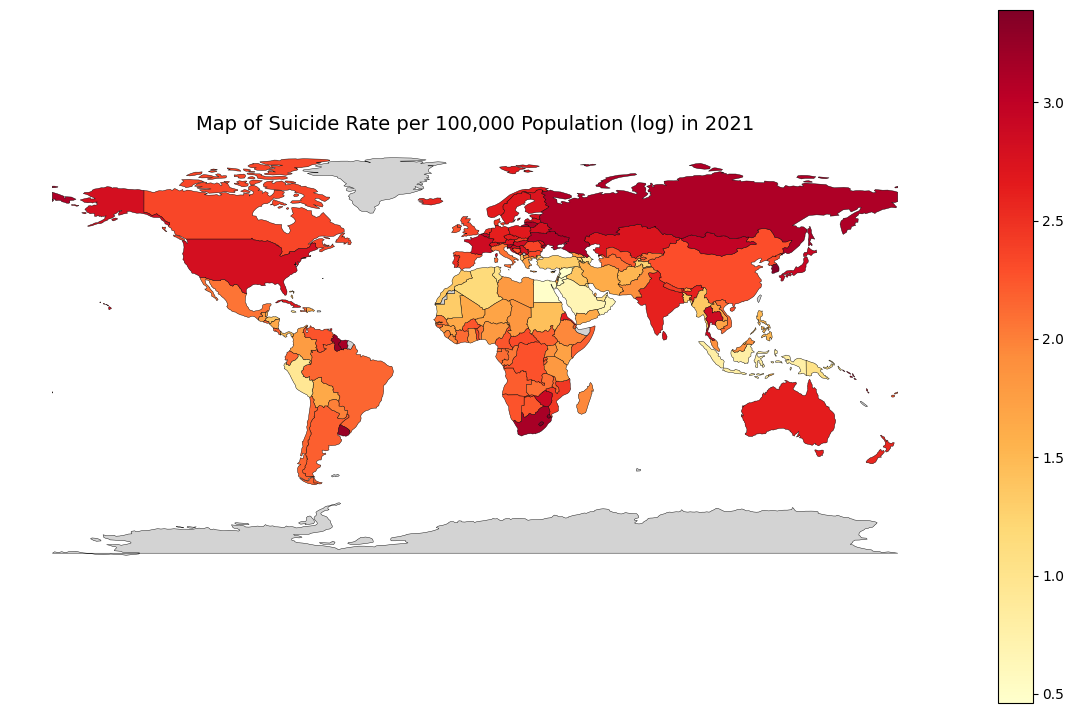

In [18]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

gdf = gpd.read_file('countries.geo.json')
df_merged_2021 = df_merged_2021[df_merged_2021['DIM_TIME']==2021]

gdf_merged = gdf.merge(
    df_merged_2021,
    how='left',
    left_on='id',
    right_on='Alpha-3 code'
)
gdf_merged['RATE_LOG'] = np.log1p(gdf_merged['RATE_PER_100000_N'])


fig, ax = plt.subplots(1, 1, figsize=(15, 9))

gdf_merged.plot(
    column='RATE_LOG',
    cmap='YlOrRd',
    linewidth=0.3,
    edgecolor='black',
    legend=True,
    ax=ax,
    missing_kwds={
        "color": "lightgrey",
        "label": "No data"
    }
)


ax.set_title('Map of Suicide Rate per 100,000 Population (log) in 2021', fontsize=14)
ax.axis('off')

plt.show()


In [19]:
import pandas as pd
import numpy as np

df3 = pd.read_csv('wgm_full_wave2_public_file_final (1)_csv.csv')
continent = pd.read_csv('Countries by continents.csv')

df3['COUNTRYNEW_clean'] = df3['COUNTRYNEW'].str.strip()
continent['Country_clean'] = continent['Country'].str.strip()

df3_merged = df3.merge(
    continent[['Country_clean', 'Continent']],
    left_on='COUNTRYNEW_clean',
    right_on='Country_clean',
    how='left'
)

print("Missing continents:", df3_merged[df3_merged['Continent'].isna()]['COUNTRYNEW'].unique())

manual_continent = {
    'Czech Republic': 'Europe',
    'Myanmar': 'Asia',
    'Burkina Faso': 'Africa',
    'Bosnia Herzegovina': 'Europe',
    'Congo Brazzaville': 'Africa',
    'North Macedonia': 'Europe',
    'Kosovo': 'Europe'
}

mask = df3_merged['Continent'].isna() & df3_merged['COUNTRYNEW'].isin(manual_continent.keys())
df3_merged.loc[mask, 'Continent'] = df3_merged.loc[mask, 'COUNTRYNEW'].map(manual_continent)

print("Still missing:", df3_merged[df3_merged['Continent'].isna()]['COUNTRYNEW'].unique())

df3_merged['MH7A'] = pd.to_numeric(df3_merged['MH7A'], errors='coerce')
df3_merged['Depressed'] = np.where(df3_merged['MH7A'] == 1, 1, 0)

print(df3_merged['Depressed'].value_counts())

/tmp/ipython-input-540987743.py:4: DtypeWarning: Columns (9,11,13,20,31,32,33,34,35,36,37,39,40,41,42,43,44,45,47,71,72,73,74,75,76,84,88) have mixed types. Specify dtype option on import or set low_memory=False.
  df3 = pd.read_csv('wgm_full_wave2_public_file_final (1)_csv.csv')


Missing continents: ['Czech Republic' 'Myanmar' 'Burkina Faso' 'Bosnia Herzegovina'
 'Congo Brazzaville' 'North Macedonia' 'Kosovo']
Still missing: []
Depressed
0    95117
1    23971
Name: count, dtype: int64


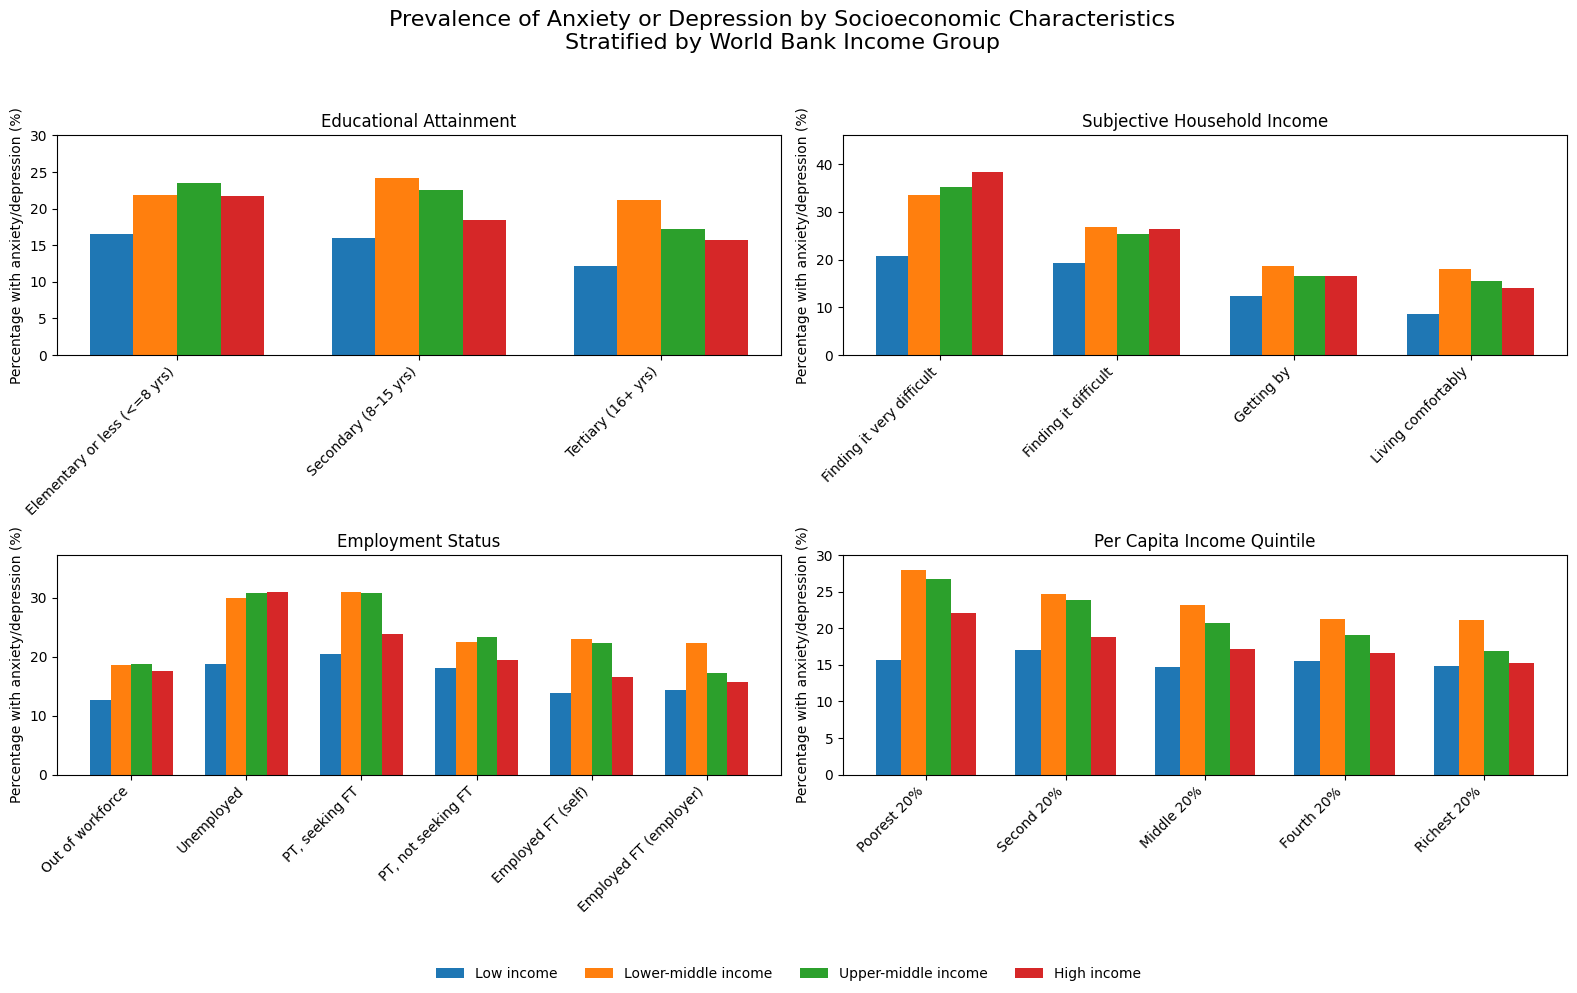

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


df = df3.copy()


num_cols = [
    'MH7A',
    'Household_Income',
    'EMP_2010',
    'Education',
    'Subjective_Income',
    'wbi'
]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

## if respondent have felt anxious/depressed, then 1, else 0, create binary variable
df['Depressed'] = np.where(df['MH7A'] == 1, 1, 0)


education_labels = {
    1: 'Elementary or less (<=8 yrs)',
    2: 'Secondary (8–15 yrs)',
    3: 'Tertiary (16+ yrs)'
}

subjective_income_labels = {
    1: 'Living comfortably',
    2: 'Getting by',
    3: 'Finding it difficult',
    4: 'Finding it very difficult',
    5: 'DK',
    6: 'Refused'
}

employment_labels = {
    1: 'Employed FT (employer)',
    2: 'Employed FT (self)',
    3: 'PT, not seeking FT',
    4: 'Unemployed',
    5: 'PT, seeking FT',
    6: 'Out of workforce'
}

hh_income_labels = {
    1: 'Poorest 20%',
    2: 'Second 20%',
    3: 'Middle 20%',
    4: 'Fourth 20%',
    5: 'Richest 20%'
}

wbi_labels = {
    1: 'Low income',
    2: 'Lower-middle income',
    3: 'Upper-middle income',
    4: 'High income'
}


df['Education'] = df['Education'].map(education_labels)
df['SubjectiveIncome'] = df['Subjective_Income'].map(subjective_income_labels)
df['Employment'] = df['EMP_2010'].map(employment_labels)
df['HHIncome'] = df['Household_Income'].map(hh_income_labels)
df['wbi'] = df['wbi'].map(wbi_labels)

## order for better visualisation
education_order = [
    'Elementary or less (<=8 yrs)',
    'Secondary (8–15 yrs)',
    'Tertiary (16+ yrs)'
]

subjective_income_order = [
    'Finding it very difficult',
    'Finding it difficult',
    'Getting by',
    'Living comfortably'
]

employment_order = [
    'Out of workforce',
    'Unemployed',
    'PT, seeking FT',
    'PT, not seeking FT',
    'Employed FT (self)',
    'Employed FT (employer)'
]

hh_income_order = [
    'Poorest 20%',
    'Second 20%',
    'Middle 20%',
    'Fourth 20%',
    'Richest 20%'
]

wbi_order = [
    'Low income',
    'Lower-middle income',
    'Upper-middle income',
    'High income'
]

order_map = {
    'Education': education_order,
    'SubjectiveIncome': subjective_income_order,
    'Employment': employment_order,
    'HHIncome': hh_income_order
}


fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

variables = [
    ('Education', 'Educational Attainment'),
    ('SubjectiveIncome', 'Subjective Household Income'),
    ('Employment', 'Employment Status'),
    ('HHIncome', 'Per Capita Income Quintile')
]

bar_width = 0.18


for ax, (var, title) in zip(axes, variables):

    temp = df.copy()

    # Drop DK/Refused for subjective income
    if var == 'SubjectiveIncome':
        temp = temp[~temp[var].isin(['DK', 'Refused'])]

    x = np.arange(len(order_map[var]))

    for i, wbi in enumerate(wbi_order):

        temp_wbi = temp[temp['wbi'] == wbi]

        rates = (
            temp_wbi
            .groupby(var)['Depressed']
            .mean()
            .reindex(order_map[var], fill_value=0) * 100
        )

        ax.bar(
            x + i * bar_width,
            rates.values,
            width=bar_width,
            label=wbi
        )

    ax.set_xticks(x + bar_width * 1.5)
    ax.set_xticklabels(order_map[var], rotation=45, ha='right')
    ax.set_title(title)
    ax.set_ylabel('Percentage with anxiety/depression (%)')
    ax.set_ylim(0, max(30, rates.max() * 1.2))


handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='lower center',
    ncol=4,
    frameon=False
)

fig.suptitle(
    'Prevalence of Anxiety or Depression by Socioeconomic Characteristics\n'
    'Stratified by World Bank Income Group',
    fontsize=16
)

plt.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.show()


In [21]:
##split by country
df_asia = df3_merged[df3_merged['Continent'] == 'Asia']
df_malaysia=df3_merged[df3_merged['COUNTRYNEW']=='Malaysia']
df_costarica = df3_merged[df3_merged['COUNTRYNEW'] == 'Costa Rica']
df_USA = df3_merged[df3_merged['COUNTRYNEW'] == 'United States']
df_hongkong = df3_merged[df3_merged['COUNTRYNEW'] == 'Hong Kong']

print(df_hongkong)

['Indonesia' 'Philippines' 'Vietnam' 'Thailand' 'Cambodia' 'Laos'
 'Myanmar' 'Malaysia']
      COUNTRYNEW  WPID_RANDOM       WGT        PROJWT  FIELD_DATE  YEAR_WAVE  \
24126  Hong Kong    180920852  0.710939   4648.199659  12/01/2020       2020   
24127  Hong Kong    138631927  1.069651   6993.498974  12/01/2020       2020   
24128  Hong Kong    202433306  0.778992   5093.138390  12/01/2020       2020   
24129  Hong Kong    173389757  0.667458   4363.913663  12/01/2020       2020   
24130  Hong Kong    118105264  1.544498  10098.102460  12/01/2020       2020   
...          ...          ...       ...           ...         ...        ...   
25125  Hong Kong    172555327  1.357988   8878.679678  12/01/2020       2020   
25126  Hong Kong    116481827  2.131710  13937.355360  12/01/2020       2020   
25127  Hong Kong    158301977  0.530944   3471.371299  12/01/2020       2020   
25128  Hong Kong    133527732  2.121757  13872.285870  12/01/2020       2020   
25129  Hong Kong    187249556  

In [22]:
## if no response then 99
mh9_cols = ['MH9A','MH9B','MH9C','MH9D','MH9E','MH9F','MH9G','MH9H']

df_malaysia[mh9_cols] = df_malaysia[mh9_cols].fillna(99)
df_costarica[mh9_cols] = df_costarica[mh9_cols].fillna(99)
df_USA[mh9_cols] = df_USA[mh9_cols].fillna(99)
df_hongkong[mh9_cols] = df_hongkong[mh9_cols].fillna(99)

/tmp/ipython-input-1471384722.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_malaysia[mh9_cols] = df_malaysia[mh9_cols].fillna(99)
/tmp/ipython-input-1471384722.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_costarica[mh9_cols] = df_costarica[mh9_cols].fillna(99)
/tmp/ipython-input-1471384722.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://p

/tmp/ipython-input-3163323368.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_country[mh9_cols] = df_country[mh9_cols].apply(
/tmp/ipython-input-3163323368.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_country[mh9_cols] = df_country[mh9_cols].apply(
/tmp/ipython-input-3163323368.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydat

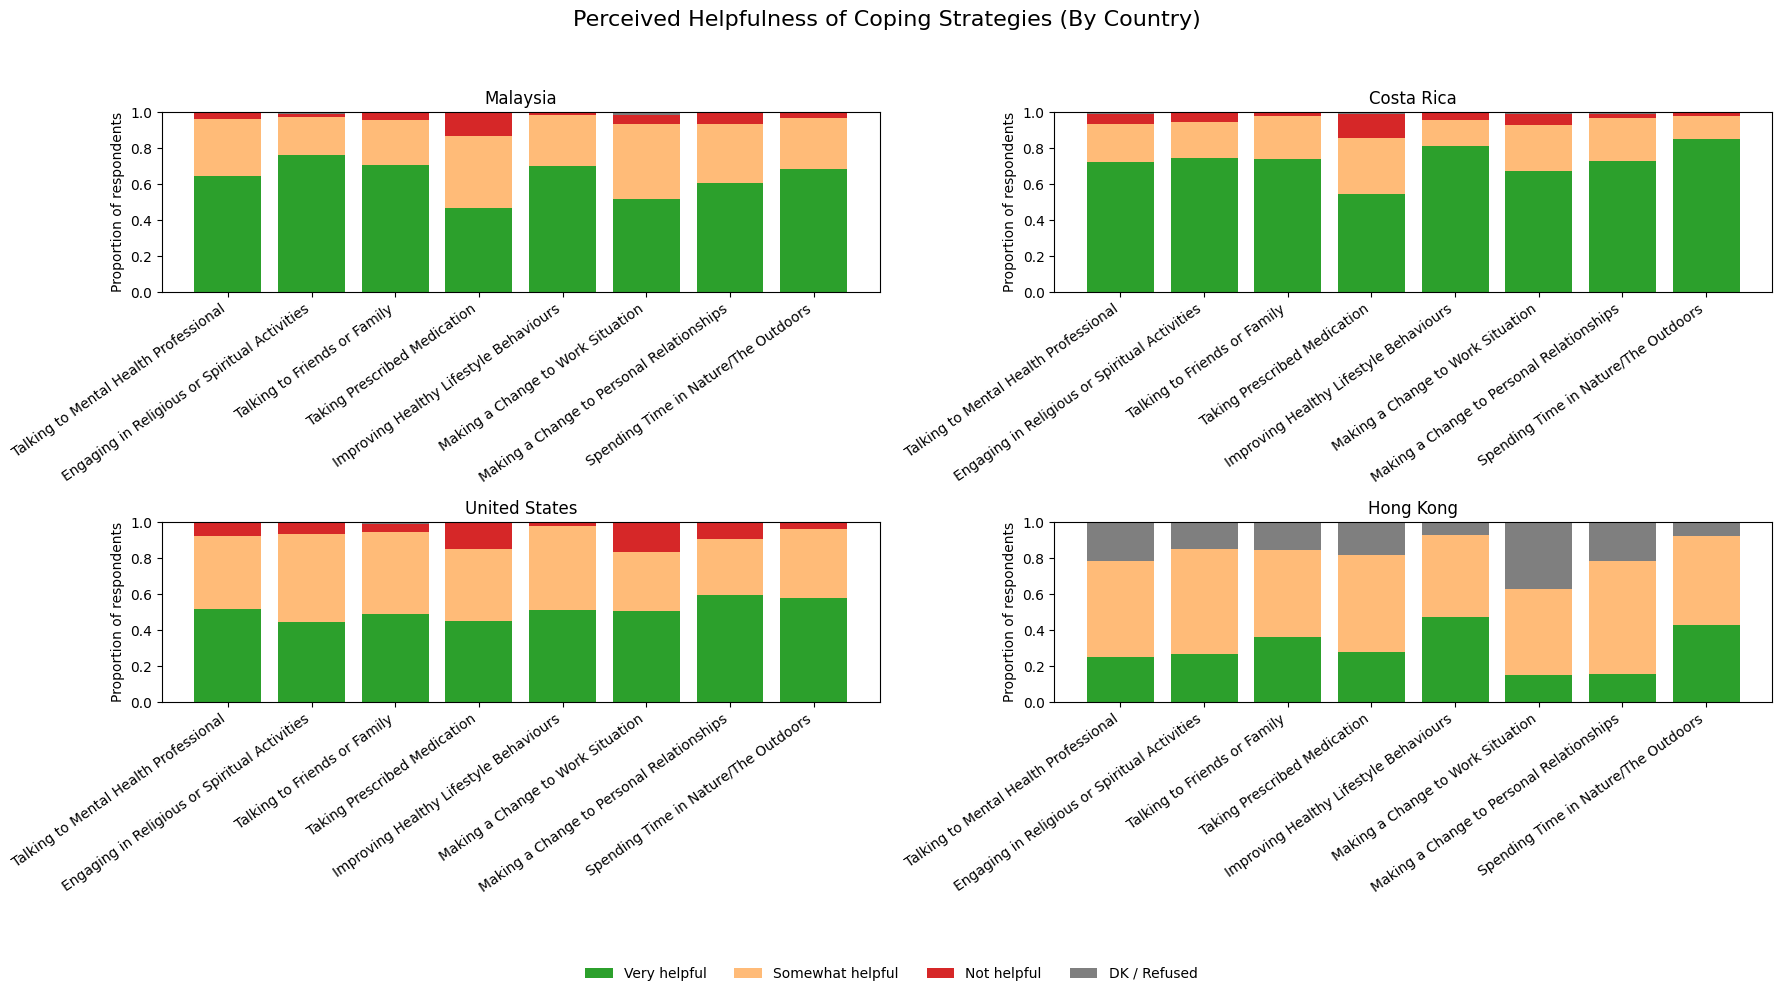

In [23]:
import matplotlib.pyplot as plt
import pandas as pd

mh9_cols = ['MH9A','MH9B','MH9C','MH9D','MH9E','MH9F','MH9G','MH9H']

dfs = [
    (df_malaysia, 'Malaysia'),
    (df_costarica, 'Costa Rica'),
    (df_USA, 'United States'),
    (df_hongkong, 'Hong Kong')
]

labels = {
    1: 'Very helpful',
    2: 'Somewhat helpful',
    3: 'Not helpful',
    99: 'DK / Refused'
}

colors = {
    1: '#2ca02c',
    2: '#ffbb78',
    3: '#d62728',
    99: '#7f7f7f'
}

question_labels = [
    "Talking to Mental Health Professional",
    "Engaging in Religious or Spiritual Activities",
    "Talking to Friends or Family",
    "Taking Prescribed Medication",
    "Improving Healthy Lifestyle Behaviours",
    "Making a Change to Work Situation",
    "Making a Change to Personal Relationships",
    "Spending Time in Nature/The Outdoors"
]

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()

for ax, (df_country, country_name) in zip(axes, dfs):

    df_country[mh9_cols] = df_country[mh9_cols].apply(
        pd.to_numeric, errors='coerce'
    )

    likert_pct = (
        df_country[mh9_cols]
        .apply(lambda x: x.value_counts(normalize=True))
        .T
        .fillna(0)
    )

    likert_pct = likert_pct.reindex(columns=[1, 2, 3, 99], fill_value=0)

    bottom = pd.Series([0]*len(likert_pct), index=likert_pct.index)

    for response in likert_pct.columns:
        ax.bar(
            likert_pct.index,
            likert_pct[response],
            bottom=bottom,
            label=labels[response],
            color=colors[response]
        )
        bottom += likert_pct[response]

    ax.set_ylabel('Proportion of respondents')
    ax.set_title(country_name)
    ax.set_ylim(0, 1)
    ax.set_xticks(range(len(mh9_cols)))
    ax.set_xticklabels(question_labels, rotation=35, ha='right')

handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, legend_labels,
    loc='lower center',
    ncol=4,
    frameon=False
)

fig.suptitle(
    'Perceived Helpfulness of Coping Strategies (By Country)',
    fontsize=16
)

plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.show()
